# Assignment 1

Deadline: 19.03.2026, 12:00 CET

<Marcel Blagotinsek, student-id and emal address>

In [1]:
%pip install numpy pandas matplotlib scipy qpsolvers osqp cvxopt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import standard libraries
import os
import sys
import timeit
from typing import Optional

# Import third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qpsolvers

# Import local modules
cwd = os.getcwd()

if os.path.basename(cwd) == "assignments":
    project_root = os.path.dirname(cwd)
else:
    project_root = cwd

src_path = os.path.join(project_root, "src")

if project_root not in sys.path:
    sys.path.append(project_root)
if src_path not in sys.path:
    sys.path.append(src_path)

from estimation.covariance import Covariance, is_pos_def, make_pos_def
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization import Optimization, Objective
from optimization.optimization_data import OptimizationData
from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
from helper_functions import simulate_correlated_gbm

c:\Users\marce\Desktop\qpmwp-course\src\optimization\optimization.py:39: SyntaxWarning: invalid escape sequence '\l'
  risk-adjusted returns ($\lambda \cdot x^T \Sigma x - \mu^T x$).


In [3]:
#PROFESSOR'S ROOT
# Import standard libraries
#import os
#import sys
#import timeit # To compute runtimes
#from typing import Optional
#
## Import third-party libraries
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
#
## Import local modules
#project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
#src_path = os.path.join(project_root, 'qpmwp-course\\src')
#sys.path.append(project_root)
#sys.path.append(src_path)
#from estimation.covariance import Covariance, is_pos_def, make_pos_def
#from estimation.expected_return import ExpectedReturn
#from optimization.constraints import Constraints
#from optimization.optimization import Optimization, Objective
#from optimization.optimization_data import OptimizationData
#from optimization.quadratic_program import QuadraticProgram, USABLE_SOLVERS
#from helper_functions import simulate_correlated_gbm

## 1. Solver Horse Race

### 1.a)
(3 points)

Generate a synthetic dataset of dimension TxN, T=1000, N=50, and compute a vector of expected returns, q, and a covariance matrix, P, using classes ExpectedReturn and Covariance respectively.

In [4]:
# Set the dimensions
T = 1000       # Number of time steps
N = 50         # Number of assets
rnd_seed = 42  # Random seed for reproducibility

# Set random seed for reproducibility
np.random.seed(rnd_seed)

# Generate a random mean vector and covariance matrix.
# Make sure the covariance matrix is positive definite.

mu = np.random.uniform(0.02, 0.15, size=N)

# Generate a positive definite covariance matrix using a spectral construction.
# We first choose strictly positive eigenvalues and then rotate them with
# a random orthogonal matrix obtained from a QR decomposition.
# This yields a symmetric positive definite matrix by construction.
eigenvalues = np.random.uniform(0.05, 0.30, size=N)
Lambda = np.diag(eigenvalues)

H = np.random.randn(N, N)
Q, _ = np.linalg.qr(H)

sigma = Q @ Lambda @ Q.T

# Standardize sigma into a correlation matrix and then rescale it with
# randomly chosen asset volatilities. This gives a covariance matrix with
# controlled marginal variances while preserving positive definiteness.
std_devs = np.sqrt(np.diag(sigma))
corr_matrix = sigma / np.outer(std_devs, std_devs)

vols = np.random.uniform(0.10, 0.30, size=N)
sigma = np.diag(vols) @ corr_matrix @ np.diag(vols)

# Check that the covariance matrix is positive definite
print("Is sigma positive definite?", is_pos_def(sigma))

# ------------------------------------------------------------
# Naive numerical alternative:
# Start from a random matrix A and form A^T A.
# This is positive semidefinite by construction; adding a small
# diagonal shift makes it strictly positive definite.
# ------------------------------------------------------------
# A = np.random.randn(N, N)
# sigma = A.T @ A
# sigma = sigma + 1e-6 * np.eye(N)
#
# print("Is sigma positive definite?", is_pos_def(sigma))

# Generate correlated geometric Brownian motion paths and compute discrete returns

# Simulate one multivariate geometric Brownian motion path over a unit horizon.
# The helper function uses dt = 1 / T, applies a Cholesky factorization of sigma
# to induce cross-asset dependence, and evolves prices via the exact GBM update
# S_{t+1} = S_t * exp((mu - 0.5 * diag(sigma)) * dt + dW_t).
# Since the returned price paths include the initial value at t = 0, the price
# matrix has shape (T + 1, N), while the discrete return matrix has shape (T, N).
prices = simulate_correlated_gbm(mu=mu, sigma=sigma, T=T, random_seed=None)
returns = prices.pct_change().dropna()

print(prices.head())
print(returns.head())

# Compute the vector of expected returns from df using class ExpectedReturn
q = ExpectedReturn().estimate(returns, inplace=False)

# Compute the covariance matrix from df using class Covariance
P = Covariance().estimate(returns, inplace=False)


# Display the results
print("Vector of expected returns (q):")
print(q)

print("\nCovariance matrix (P):")
print(P)

Is sigma positive definite? True
    Asset_1   Asset_2   Asset_3   Asset_4   Asset_5   Asset_6   Asset_7  \
0  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
1  1.004326  1.005355  0.996352  1.000304  1.004173  1.009881  1.007808   
2  1.007695  0.995359  1.000882  0.996601  1.008570  1.013973  1.003001   
3  1.010386  0.980022  1.004617  0.999475  1.001589  1.015107  1.019261   
4  1.012257  0.986277  1.004271  1.001171  0.997994  1.013959  1.016633   

    Asset_8   Asset_9  Asset_10  ...  Asset_41  Asset_42  Asset_43  Asset_44  \
0  1.000000  1.000000  1.000000  ...  1.000000  1.000000  1.000000  1.000000   
1  1.007130  1.001727  1.010232  ...  0.995192  1.005012  0.994785  1.004578   
2  1.011989  1.004091  1.007598  ...  1.002719  1.014989  0.999056  1.002083   
3  1.006377  0.995739  1.017895  ...  1.004203  1.010339  1.000508  0.991616   
4  1.001399  0.994203  1.007395  ...  1.003113  1.004700  1.001650  0.985494   

   Asset_45  Asset_46  Asset_47  As

### 1.b)
(3 points)

Instantiate a constraints object by injecting column names of the return series created in 1.a) as ids and add:
- a budget constaint (i.e., asset weights have to sum to one)
- lower bounds of 0.0 for all assets
- upper bounds of 0.2 for all assets
- group contraints such that the sum of the weights of the first 15 assets is <= 0.3, the sum of assets 16 to 45 is <= 0.4 and the sum of assets 41 to 50 is <= 0.5

In [5]:
# Instantiate the Constraints class
constraints = Constraints(ids = returns.columns.tolist())

# Add budget constraint
# portfolio is fully invested: w1 + w2 + ... + w50 = 1
constraints.add_budget(rhs=1, sense='=')

# Add box constraints (i.e., lower and upper bounds)
# long-only positions with a 20% cap per asset: 0 <= wi <= 0.2
constraints.add_box(lower=0, upper=0.2)

# Add linear constraints (G w <= h)
G = pd.DataFrame(np.zeros((3, N)), columns=constraints.ids)

# first 15 assets cannot exceed 30% total
G.iloc[0, 0:15] = 1
# sum of assets from 16 to 45 cannot exceed 40% total
G.iloc[1, 15:45] = 1
# sum of assets from 41 to 50 cannot exceed 50% total
G.iloc[2, 40:50] = 1

h = pd.Series([0.3, 0.4, 0.5])

constraints.add_linear(G=G, sense='<=', rhs=h)

# Display some columns of the G matrix to verify that the constraints have been set up correctly
constraints.linear['G'][['Asset_1', 'Asset_15', 'Asset_16', 'Asset_40', 'Asset_41', 'Asset_50']]

,Asset_1,Asset_15,Asset_16,Asset_40,Asset_41,Asset_50
0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,1.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,1.0


### 1.c) 
(4 points)

Solve a Mean-Variance optimization problem (using coefficients P and q in the objective function) which satisfies the above defined constraints.
Repeat the task for all open-source solvers in qpsolvers that you could install and compare the results in terms of:

- runtime
- accuracy: value of the primal problem.
- reliability: are all constraints fulfilled? Extract primal residuals, dual residuals and duality gap.

Generate a DataFrame with the solvers as column names and the following row index: 'solution_found': bool, 'objective': float, 'primal_residual': float, 'dual_residual': float, 'duality_gap': float, 'runtime': float.

Put NA's for solvers where the optimization failed for some reason.




In [6]:
import qpsolvers
print(qpsolvers.available_solvers)

['clarabel', 'cvxopt', 'daqp', 'ecos', 'highs', 'jaxopt_osqp', 'osqp', 'piqp', 'qpalm', 'qpax', 'quadprog', 'scs', 'sip']


In [7]:
# Extract the constraints in the format required by the solver
GhAb = constraints.to_GhAb()

# Define a dictionary to store the results in case a solver fails
result_on_fail = {
    'solution_found': False,
    'objective': np.nan,
    'primal_residual': np.nan,
    'dual_residual': np.nan,
    'duality_gap': np.nan,
    'runtime': np.nan,
}

risk_aversion = 2

# Include all installed/open-source solvers except qpalm, which crashes the kernel
solvers_to_test = ['cvxopt', 'osqp', 'quadprog', 'daqp', 'qtqp']
results = {}

for solver in solvers_to_test:
    try:
        qp = QuadraticProgram(
            P=P.to_numpy() * risk_aversion,
            q=-q.to_numpy(),
            G=GhAb['G'],
            h=GhAb['h'],
            A=GhAb['A'],
            b=GhAb['b'],
            lb=constraints.box['lower'].to_numpy(),
            ub=constraints.box['upper'].to_numpy(),
            solver=solver,
        )

        start = timeit.default_timer()
        qp.solve()
        runtime = timeit.default_timer() - start

        solution = qp.results.get('solution')
        found = getattr(solution, 'found', False)

        gap = np.nan
        if found:
            gap = solution.duality_gap()
            if isinstance(gap, (list, tuple, np.ndarray)):
                gap = gap[0]

        results[solver] = {
            'solution_found': found,
            'objective': qp.objective_value() if found else np.nan,
            'primal_residual': solution.primal_residual() if found else np.nan,
            'dual_residual': solution.dual_residual() if found else np.nan,
            'duality_gap': gap if found else np.nan,
            'runtime': runtime,
        }

    except Exception as e:
        print(f"{solver} failed: {e}")
        results[solver] = result_on_fail.copy()

# Add qpalm manually as failed because it crashes the kernel
results['qpalm'] = result_on_fail.copy()

# Final table: solvers as columns
results_df = pd.DataFrame(results)
results_df

qtqp failed: Solver 'qtqp' is not available. Choose from: {'osqp', 'daqp', 'cvxopt', 'qpalm', 'quadprog'}


,cvxopt,osqp,quadprog,daqp,qtqp,qpalm
solution_found,True,True,True,True,False,False
objective,-0.000301,-0.000304,-0.000301,-0.000301,NaN,NaN
primal_residual,0.0,0.000513,0.0,0.0,NaN,NaN
dual_residual,0.0,0.000001,0.0,0.0,NaN,NaN
duality_gap,0.0,0.000002,0.0,0.0,NaN,NaN
runtime,0.08169,0.003777,0.000732,0.00095,NaN,NaN


Print and visualize the results

Successful solvers to plot: ['cvxopt', 'osqp', 'quadprog', 'daqp']


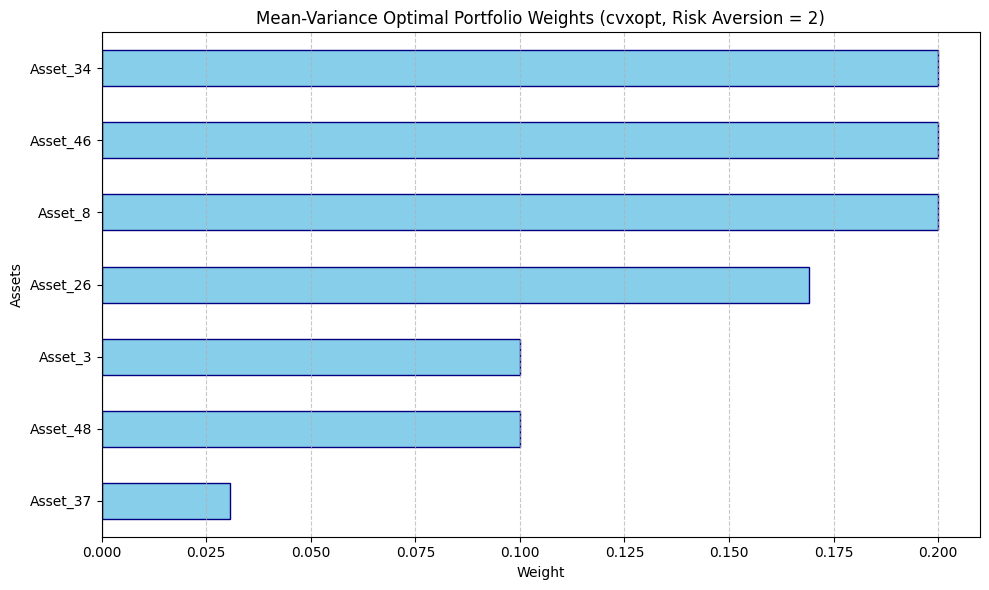

Optimal portfolio weights for cvxopt:
Asset_1     5.741310e-07
Asset_2     8.391859e-07
Asset_3     1.000122e-01
Asset_4     4.248522e-07
Asset_5     3.601299e-07
Asset_6     4.000135e-07
Asset_7     4.879140e-07
Asset_8     1.999794e-01
Asset_9     5.233559e-07
Asset_10    3.812998e-07
Asset_11    3.454240e-07
Asset_12    5.810384e-07
Asset_13    1.541948e-06
Asset_14    4.365845e-07
Asset_15    1.104133e-06
Asset_16    3.565307e-07
Asset_17    8.966277e-07
Asset_18    5.154404e-07
Asset_19    4.770686e-07
Asset_20    1.347557e-06
Asset_21    2.730845e-06
Asset_22    4.831679e-07
Asset_23    1.163672e-06
Asset_24    1.165356e-06
Asset_25    5.891796e-07
Asset_26    1.692166e-01
Asset_27    3.461407e-07
Asset_28    6.113312e-07
Asset_29    6.293413e-07
Asset_30    7.854980e-07
Asset_31    1.584594e-06
Asset_32    7.937263e-07
Asset_33    1.861572e-05
Asset_34    1.999993e-01
Asset_35    5.253456e-07
Asset_36    8.275647e-07
Asset_37    3.074046e-02
Asset_38    9.717682e-07
Asset_39    

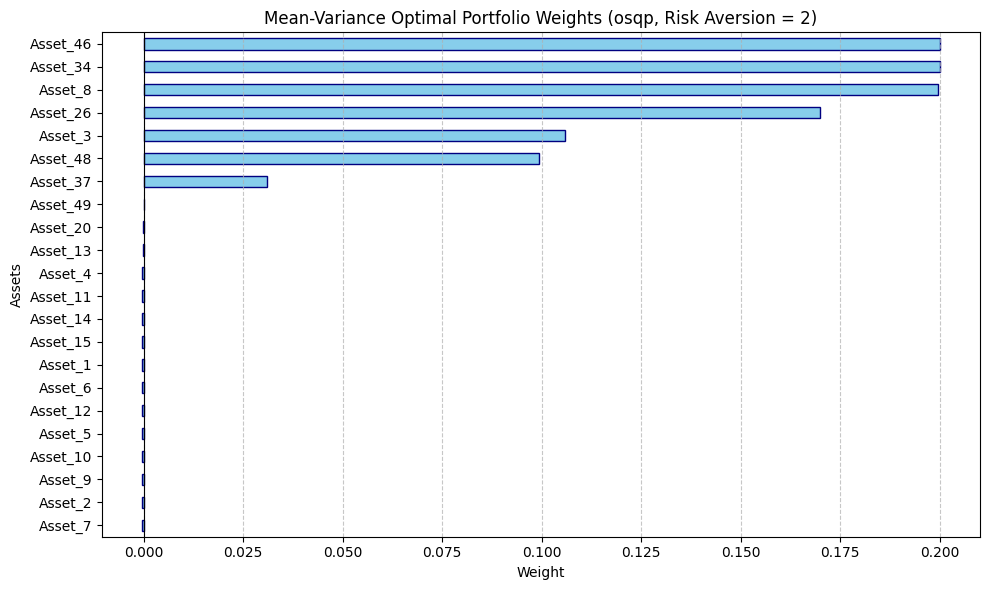

Optimal portfolio weights for osqp:
Asset_1    -0.000396
Asset_2    -0.000439
Asset_3     0.105926
Asset_4    -0.000346
Asset_5    -0.000402
Asset_6    -0.000398
Asset_7    -0.000513
Asset_8     0.199613
Asset_9    -0.000419
Asset_10   -0.000417
Asset_11   -0.000352
Asset_12   -0.000400
Asset_13   -0.000305
Asset_14   -0.000364
Asset_15   -0.000381
Asset_16   -0.000047
Asset_17   -0.000023
Asset_18   -0.000037
Asset_19   -0.000038
Asset_20   -0.000128
Asset_21   -0.000035
Asset_22   -0.000037
Asset_23   -0.000065
Asset_24   -0.000027
Asset_25   -0.000015
Asset_26    0.169797
Asset_27    0.000015
Asset_28   -0.000029
Asset_29   -0.000039
Asset_30   -0.000022
Asset_31   -0.000039
Asset_32   -0.000071
Asset_33   -0.000008
Asset_34    0.200034
Asset_35   -0.000078
Asset_36   -0.000024
Asset_37    0.031043
Asset_38   -0.000009
Asset_39    0.000024
Asset_40   -0.000031
Asset_41   -0.000012
Asset_42   -0.000017
Asset_43    0.000018
Asset_44    0.000031
Asset_45   -0.000038
Asset_46    0.20006

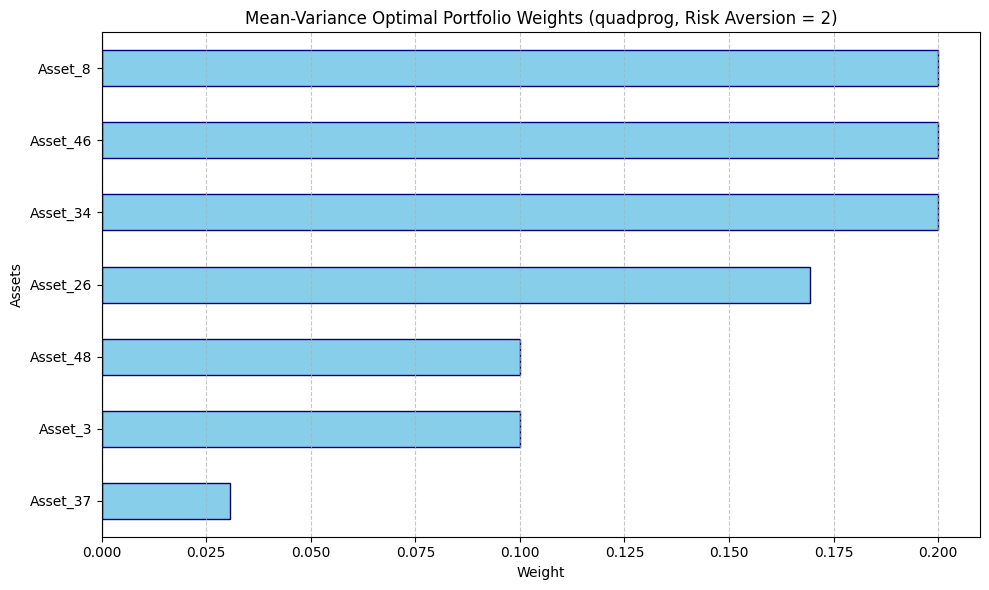

Optimal portfolio weights for quadprog:
Asset_1     3.345666e-17
Asset_2     2.217046e-17
Asset_3     1.000000e-01
Asset_4     1.602574e-16
Asset_5    -3.442014e-17
Asset_6    -2.753769e-17
Asset_7    -1.298111e-16
Asset_8     2.000000e-01
Asset_9     8.602377e-17
Asset_10    1.312854e-16
Asset_11    1.171503e-15
Asset_12    5.822731e-17
Asset_13    1.387779e-17
Asset_14    3.264483e-17
Asset_15    4.866053e-17
Asset_16   -2.664956e-16
Asset_17    1.113782e-16
Asset_18    6.137109e-15
Asset_19   -4.223374e-16
Asset_20    1.075974e-17
Asset_21    0.000000e+00
Asset_22   -5.948294e-16
Asset_23    2.852176e-17
Asset_24   -2.683568e-17
Asset_25   -9.004346e-16
Asset_26    1.693547e-01
Asset_27    1.062404e-15
Asset_28    1.329074e-16
Asset_29    6.581557e-16
Asset_30   -3.408430e-16
Asset_31    6.270505e-17
Asset_32   -3.371097e-17
Asset_33   -7.697379e-19
Asset_34    2.000000e-01
Asset_35   -7.998402e-17
Asset_36   -3.731111e-16
Asset_37    3.064528e-02
Asset_38   -4.581844e-16
Asset_39  

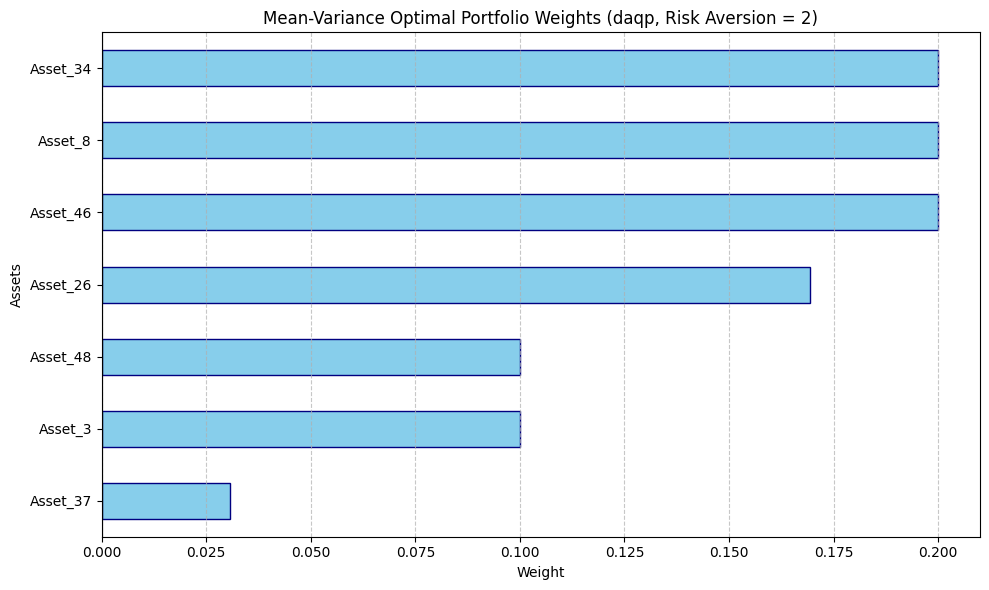

Optimal portfolio weights for daqp:
Asset_1     2.083562e-15
Asset_2    -2.055278e-15
Asset_3     1.000000e-01
Asset_4     3.065630e-14
Asset_5    -2.674756e-15
Asset_6     1.479606e-15
Asset_7    -2.104356e-15
Asset_8     2.000000e-01
Asset_9     1.711324e-15
Asset_10    2.505194e-15
Asset_11   -6.977789e-16
Asset_12   -3.491128e-16
Asset_13   -2.442747e-14
Asset_14    2.517410e-17
Asset_15    7.246262e-16
Asset_16    1.619215e-15
Asset_17    8.619520e-16
Asset_18   -1.057279e-14
Asset_19   -1.050621e-15
Asset_20    1.616356e-17
Asset_21   -1.383016e-15
Asset_22   -7.182618e-15
Asset_23   -8.656691e-15
Asset_24   -1.524200e-15
Asset_25    5.865956e-15
Asset_26    1.693547e-01
Asset_27    2.200534e-15
Asset_28    1.755980e-14
Asset_29    8.711881e-16
Asset_30    8.209891e-15
Asset_31   -9.741851e-16
Asset_32   -9.465124e-16
Asset_33   -4.198258e-15
Asset_34    2.000000e-01
Asset_35    6.115799e-17
Asset_36   -4.462799e-15
Asset_37    3.064528e-02
Asset_38   -9.420171e-16
Asset_39   -3.

In [8]:
# Solvers you want to visualize
solvers_to_plot = ['cvxopt', 'osqp', 'quadprog', 'daqp']

# Keep only those that actually found a solution in results_df
successful_solvers = [
    s for s in solvers_to_plot
    if s in results_df.columns and bool(results_df.loc['solution_found', s])
]

print("Successful solvers to plot:", successful_solvers)

weights_by_solver = {}

for solver_to_plot in successful_solvers:
    qp_plot = QuadraticProgram(
        P=P.to_numpy() * risk_aversion,
        q=-q.to_numpy(),
        G=GhAb['G'],
        h=GhAb['h'],
        A=GhAb['A'],
        b=GhAb['b'],
        lb=constraints.box['lower'].to_numpy(),
        ub=constraints.box['upper'].to_numpy(),
        solver=solver_to_plot,
    )

    qp_plot.solve()
    solution_plot = qp_plot.results.get('solution')

    weights = pd.Series(
        solution_plot.x,
        index=returns.columns,
        name=f"Optimal Weights ({solver_to_plot})"
    )
    weights_by_solver[solver_to_plot] = weights

    weights_filtered = weights[weights.abs() > 1e-4]

    plt.figure(figsize=(10, 6))
    weights_filtered.sort_values().plot(
        kind='barh',
        color='skyblue',
        edgecolor='navy'
    )

    plt.title(f'Mean-Variance Optimal Portfolio Weights ({solver_to_plot}, Risk Aversion = {risk_aversion})')
    plt.xlabel('Weight')
    plt.ylabel('Assets')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"Optimal portfolio weights for {solver_to_plot}:")
    print(weights)

    print(f"\nTop 5 Holdings for {solver_to_plot}:")
    print(weights.sort_values(ascending=False).head(5))
    print("\n" + "-" * 60 + "\n")

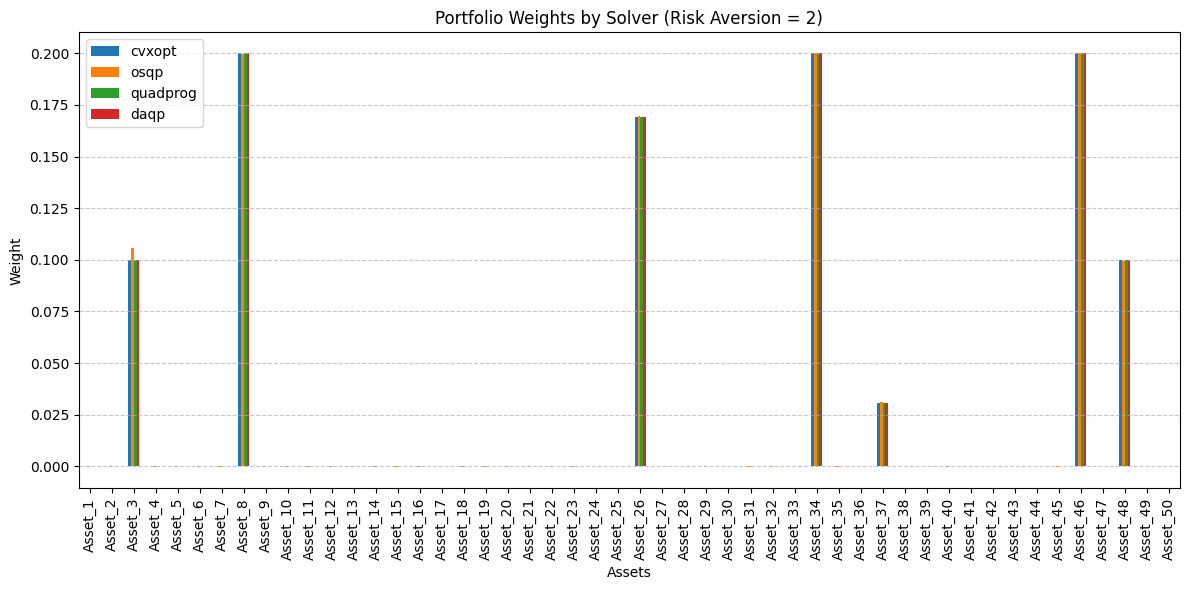

In [9]:
weights_compare_df = pd.DataFrame(weights_by_solver)

plt.figure(figsize=(12, 6))
weights_compare_df.plot(kind='bar', ax=plt.gca())
plt.title(f'Portfolio Weights by Solver (Risk Aversion = {risk_aversion})')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2. Analytical Solution to Minimum-Variance Problem

(5 points)

- Create a `MinVariance` class that follows the structure of the `MeanVariance` class.
- Implement the `solve` method in `MinVariance` such that if `solver_name = 'analytical'`, the analytical solution is computed and stored within the object (if such a solution exists). If not, call the `solve` method from the parent class.
- Create a `Constraints` object by injecting the same ids as in part 1.b) and add a budget constraint.
- Instantiate a `MinVariance` object by setting `solver_name = 'analytical'` and passing instances of `Constraints` and `Covariance` as arguments.
- Create an `OptimizationData` object that contains an element `return_series`, which consists of the synthetic data generated in part 1.a).
- Solve the optimization problem using the created `MinVariance` object and compare the results to those obtained in part 1.c).


Asset_1     0.004001
Asset_2     0.012058
Asset_3     0.038712
Asset_4     0.075012
Asset_5     0.023790
Asset_6    -0.004303
Asset_7     0.006397
Asset_8     0.008923
Asset_9    -0.002294
Asset_10    0.014340
Asset_11    0.008019
Asset_12    0.008548
Asset_13    0.017138
Asset_14    0.009928
Asset_15   -0.001887
Asset_16    0.016335
Asset_17    0.036146
Asset_18    0.034152
Asset_19    0.029072
Asset_20    0.008207
Asset_21    0.016694
Asset_22    0.022691
Asset_23    0.073971
Asset_24   -0.001732
Asset_25    0.017848
Asset_26   -0.009655
Asset_27   -0.001180
Asset_28    0.097097
Asset_29    0.004808
Asset_30    0.062156
Asset_31    0.023553
Asset_32    0.011919
Asset_33    0.039555
Asset_34    0.010168
Asset_35    0.025415
Asset_36    0.040932
Asset_37    0.013188
Asset_38    0.020456
Asset_39    0.002303
Asset_40    0.008778
Asset_41   -0.001705
Asset_42   -0.001205
Asset_43   -0.002734
Asset_44    0.012455
Asset_45    0.013849
Asset_46    0.052849
Asset_47    0.024830
Asset_48   -0

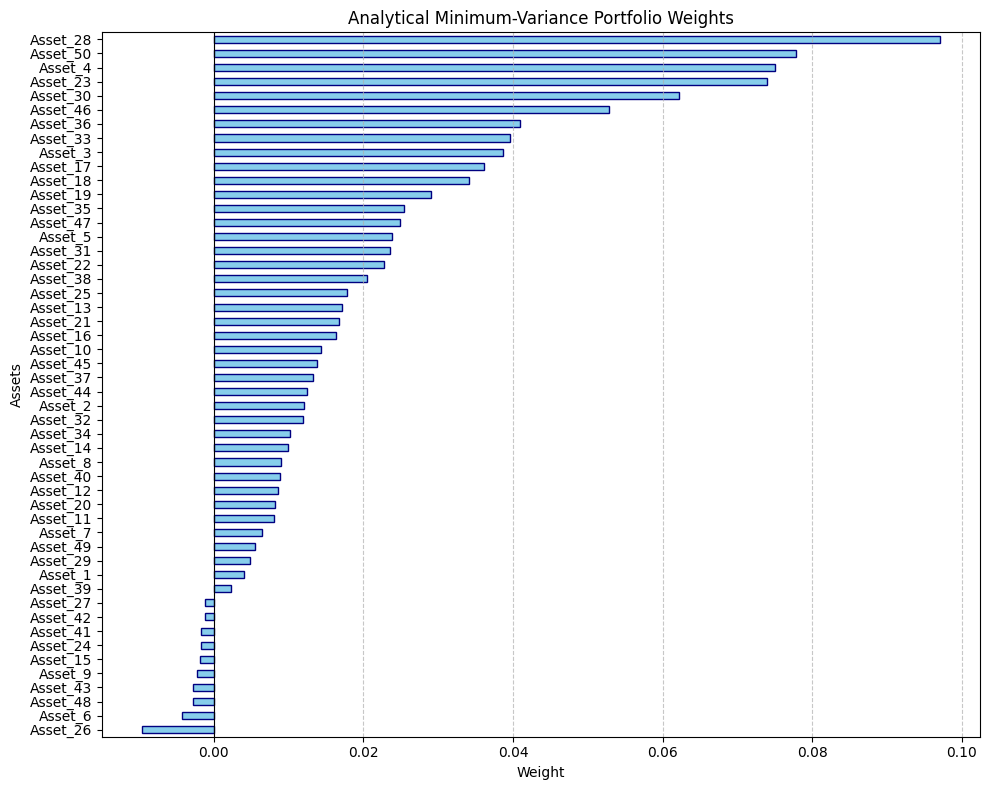

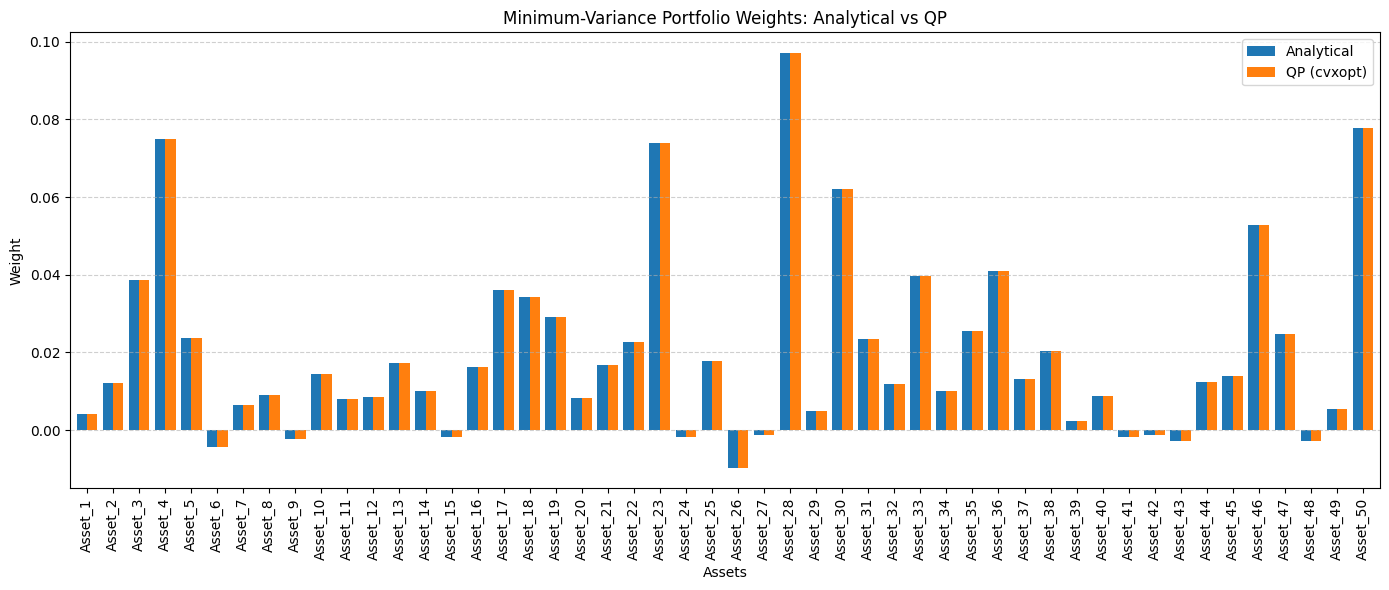

In [16]:
# Define class MinVariance
class MinVariance(Optimization):

    def __init__(self,
                 constraints: Constraints,
                 covariance: Optional[Covariance] = None,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        n_assets = covmat.shape[0] #fpr vector of zeros
        self.objective = Objective(
            q = np.zeros(n_assets),
            P = covmat * 2,
        )


    def solve(self) -> None:
        if self.params.get('solver_name') == 'analytical':
            # lecture formula only for equality-constrained problems:
            #   min_x x' Σ x
            #   s.t.  A x = b

            # no inequality constraints, no box constraints, only linear equality constraints
            GhAb = self.constraints.to_GhAb()
            A = GhAb['A']
            b = GhAb['b']
            G = GhAb['G']
            h = GhAb['h']
            if G is not None or h is not None:
                raise ValueError(
                    "Analytical solution only applies to equality constraints Ax=b. "
                    "Found inequality constraints Gx<=h."
                )
            
            # Reject box constraints unless they are absent / unbounded
            lower = self.constraints.box.get('lower')
            upper = self.constraints.box.get('upper')
            if lower is not None or upper is not None:
                lower_np = None if lower is None else np.asarray(lower, dtype=float)
                upper_np = None if upper is None else np.asarray(upper, dtype=float)

                has_finite_lower = lower_np is not None and np.isfinite(lower_np).any()
                has_finite_upper = upper_np is not None and np.isfinite(upper_np).any()

                if has_finite_lower or has_finite_upper:
                    raise ValueError(
                        "Analytical solution only applies to equality constraints Ax=b. "
                        "Box constraints are not allowed."
                    )
                
            if A is None or b is None:
                raise ValueError(
                    "Analytical minimum-variance solution requires equality constraints Ax=b."
                )
            
            # extract sigma from the quadratic term P = 2*Sigma
            P = self.objective.coefficients['P']
            Sigma = np.asarray(P, dtype=float) / 2.0
            A = np.asarray(A, dtype=float)
            b = np.asarray(b, dtype=float).reshape(-1, 1)

            # Check assumptions listed in the lecture slides
            if not is_pos_def(Sigma):
                raise ValueError(
                    "Analytical solution requires Sigma to be symmetric positive definite."
                )
            
            Sigma_inv = np.linalg.inv(Sigma)
            middle = A @ Sigma_inv @ A.T

            if np.linalg.matrix_rank(middle) < middle.shape[0]:
                raise ValueError(
                    "Analytical solution requires A Sigma^{-1} A^T to be invertible."
                )
            
            middle_inv = np.linalg.inv(middle)

            # Lecture formula:
            # x* = Sigma^{-1} A^T (A Sigma^{-1} A^T)^{-1} b
            x_star = Sigma_inv @ A.T @ middle_inv @ b
            x_star = x_star.flatten()

            self.results = {
                'weights': x_star,
                'status': True,
                'solver': 'analytical'
            }           
            
            return None
        else:
            return super().solve()


# Create a constraints object with just a budget constraint
constraints_mv = Constraints(ids=returns.columns.tolist())
constraints_mv.add_budget(rhs=1, sense='=')

# Instantiate the MinVariance class
minvar = MinVariance(
    constraints=constraints_mv,
    covariance=Covariance(check_positive_definite=True),
    solver_name='analytical'
)

# Prepare the optimization data and prepare the optimization problem
optimization_data = OptimizationData(return_series=returns)
minvar.set_objective(optimization_data=optimization_data)

# Solve the optimization problem and print the weights
minvar.solve()

weights_minvar = pd.Series(minvar.results['weights'], index=returns.columns, name='MinVariance Weights')
print(weights_minvar)
print("\nSum of weights:", weights_minvar.sum())

# Numerical comparison against the same problem
minvar_qp = MinVariance(
    constraints=constraints_mv,
    covariance=Covariance(check_positive_definite=True),
    solver_name='cvxopt'
)

minvar_qp.set_objective(optimization_data=optimization_data)
minvar_qp.solve()

weights_minvar_qp = pd.Series(minvar_qp.results['weights'], index=returns.columns, name='MinVariance QP Weights')
print(weights_minvar_qp)
print("\nSum of weights:", weights_minvar_qp.sum())

# Compare analytical and numerical minimum-variance weights
comparison_df = pd.DataFrame({
    'Analytical': weights_minvar,
    'QP (cvxopt)': weights_minvar_qp
})

# Plot 1: Horizontal plot of the analytical solution only
plt.figure(figsize=(10, 8))
weights_minvar.sort_values().plot(
    kind='barh',
    color='skyblue',
    edgecolor='navy'
)
plt.title('Analytical Minimum-Variance Portfolio Weights')
plt.xlabel('Weight')
plt.ylabel('Assets')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot 2: side-by-side weights
plt.figure(figsize=(14, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Minimum-Variance Portfolio Weights: Analytical vs QP')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()